<a href="https://colab.research.google.com/github/ParsOner/machine-learning-classification-project/blob/main/machine_learning/adult-income-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shwetali Vitthal Bhuingade - D18000073;
Harshal Rajesh Kokitkar - D18000063;
Mustafa Oner - D18000070

In [ ]:
pip install ucimlrepo

In [ ]:
# Import Data
from ucimlrepo import fetch_ucirepo

# Correlation Matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Data Splitting
from sklearn.model_selection import StratifiedShuffleSplit



#**Import Adult Income Dataset**

In [ ]:

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# metadata
print(adult.metadata)

# variable information
print(adult.variables)


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

#**Check the missing values**


In [ ]:
y.isna().sum()
y = y.dropna()
y.isna().sum()

,0
income,0


#**Correlation Matrix**

<Axes: >

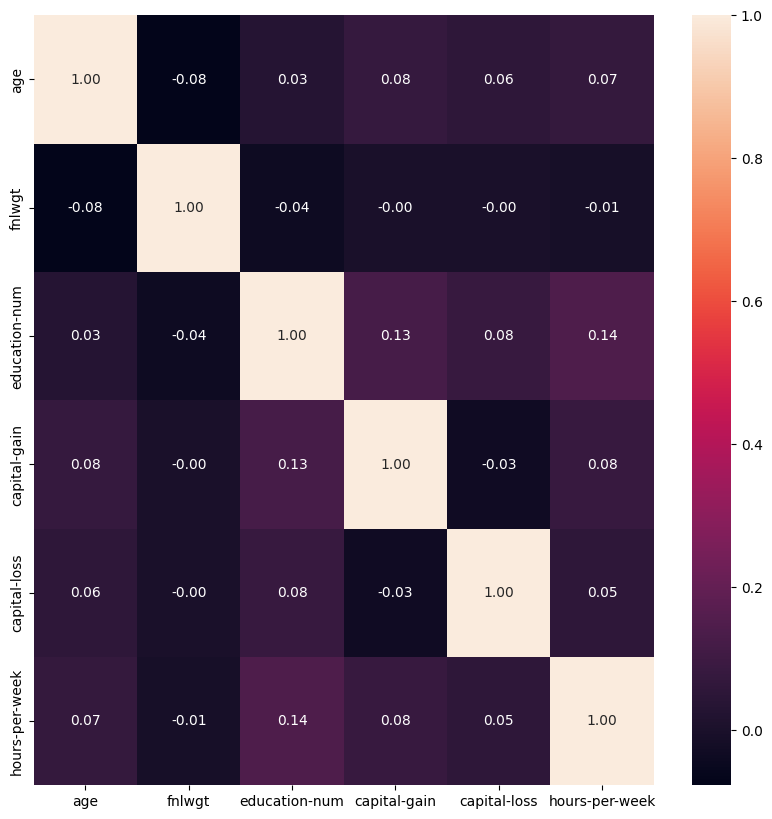

In [ ]:
# Select only the numerical columns before calculating the correlation matrix
X_numeric = X.select_dtypes(include='number')

# Calculate the correlation matrix for the numerical columns
plt.figure(figsize=(10, 10)) # To enlarge the plot
sns.heatmap(X_numeric.corr(), annot=True, fmt=".2f")

In [ ]:
y["income"]

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
...,...
48837,<=50K.
48838,<=50K.
48839,<=50K.
48840,<=50K.


In [ ]:
# Select only the numerical columns from X
X_numeric = X.select_dtypes(include='number')

# Calculate the mean and standard deviation for the numerical columns
X_numeric.mean(), X_numeric.std()

(age                   38.643585
 fnlwgt            189664.134597
 education-num         10.078089
 capital-gain        1079.067626
 capital-loss          87.502314
 hours-per-week        40.422382
 dtype: float64,
 age                   13.710510
 fnlwgt            105604.025423
 education-num          2.570973
 capital-gain        7452.019058
 capital-loss         403.004552
 hours-per-week        12.391444
 dtype: float64)

Text(0.5, 1.0, 'Distribution of Income Categories (Binary)')

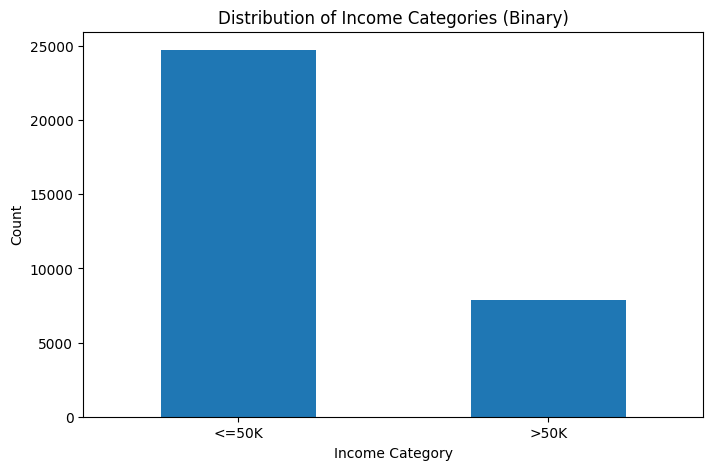

In [ ]:

# This handles cases where values might be strings with spaces or different cases
y["income_binary"] = y["income"].str.strip().str.lower().map({'<=50k': 0, '>50k': 1})

# Plot the binary distribution
plt.figure(figsize=(8, 5))
y["income_binary"].value_counts().plot(kind="bar")
plt.xticks([0, 1], ['<=50K', '>50K'], rotation=0)
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.title("Distribution of Income Categories (Binary)")


([<matplotlib.patches.Wedge at 0x7f84a3d26d50>,
 [Text(-0.7999478707000827, 0.7550386772625651, '0.0'),
  Text(0.7999479367076598, -0.7550386073288956, '1.0')],
 [Text(-0.436335202200045, 0.41183927850685365, '75.9%'),
  Text(0.436335238204178, -0.4118392403612157, '24.1%')])

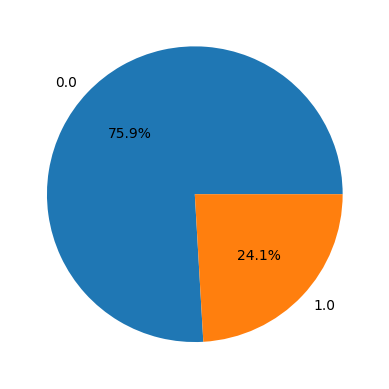

In [ ]:
plt.pie(y["income_binary"].value_counts(), labels=y["income_binary"].value_counts().index, autopct='%1.1f%%')

#**Data Spliting**

In [ ]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(exclude='object').columns.tolist()

from sklearn.model_selection import StratifiedShuffleSplit
ssp = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Define Y before using it:

# Ensure the target variable for stratification is free of NaNs
# Drop rows where 'income_binary' is NaN
y = y.dropna(subset=['income_binary'])
X = X.loc[y.index] # Also drop corresponding rows in X to maintain alignment

#now we need to split the dataset
train_idx, test_idx = next(ssp.split(X, y['income_binary'])) # Use the binary target for splitting
X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]['income_binary'] # Extract the binary target
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]['income_binary'] # Extract the binary target

In [ ]:
X_train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
15738,32,Private,37210,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States
27985,43,Private,101950,Masters,14,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,45,United-States
30673,20,?,122244,HS-grad,9,Never-married,?,Not-in-family,White,Female,0,0,28,United-States
9505,40,Local-gov,24763,Some-college,10,Divorced,Transport-moving,Unmarried,White,Male,6849,0,40,United-States
26417,24,Private,113936,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8003,35,Self-emp-not-inc,179171,HS-grad,9,Never-married,Sales,Unmarried,Black,Female,0,0,38,Germany
20560,39,Private,421633,Some-college,10,Divorced,Protective-serv,Unmarried,Black,Female,0,0,30,United-States
23650,55,Private,82098,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male,0,0,55,United-States
25301,26,Private,50053,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,55,United-States


In [ ]:
train_idx, X_train


(array([15738, 27985, 30673, ..., 23650, 25301,  5800]),
        age         workclass  fnlwgt     education  education-num  \
 15738   32           Private   37210     Bachelors             13   
 27985   43           Private  101950       Masters             14   
 30673   20                 ?  122244       HS-grad              9   
 9505    40         Local-gov   24763  Some-college             10   
 26417   24           Private  113936     Bachelors             13   
 ...    ...               ...     ...           ...            ...   
 8003    35  Self-emp-not-inc  179171       HS-grad              9   
 20560   39           Private  421633  Some-college             10   
 23650   55           Private   82098       HS-grad              9   
 25301   26           Private   50053     Bachelors             13   
 5800    19           Private  415354          10th              6   
 
            marital-status        occupation   relationship  \
 15738  Married-civ-spouse   Exec-mana

#**Random Forest Classifier**

In [ ]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler # Import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# Import necessary preprocessing tools
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline # Import Pipeline for the preprocessor

In [ ]:
# Define the preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Define the pipeline with RandomUnderSampler and RandomForest
pipe = ImbPipeline([
    ('preprocessor', preprocessor), # Use the defined preprocessor
    ('rus', RandomUnderSampler(random_state=42)),  # Add RandomUnderSampler step
    ('rf', RandomForestClassifier(random_state=42))
])

# Define the parameter grid for RandomForest
param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__bootstrap': [True, False]
}

# Perform GridSearchCV
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='f1_macro', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Evaluation
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

y_pred = grid_search.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

y_scores = grid_search.predict_proba(X_test)[:, 1]
print("ROC AUC Score:", roc_auc_score(y_test, y_scores))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found: {'rf__bootstrap': True, 'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 10, 'rf__n_estimators': 200}
Best cross-validation score: 0.7771828111700657

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.80      0.87      4945
         1.0       0.58      0.87      0.70      1568

    accuracy                           0.82      6513
   macro avg       0.76      0.84      0.78      6513
weighted avg       0.86      0.82      0.83      6513

ROC AUC Score: 0.9153313360227812


# **Logistic Regression Classifier**

In [ ]:
# Classification Using Logistic Regression Classifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score,
                            recall_score, f1_score, roc_auc_score,
                            classification_report,
                            confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)
import time
from imblearn.under_sampling import RandomUnderSampler # Import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [ ]:

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Define the pipeline with RandomUnderSampler and Logistic Regression
lr_pipe = ImbPipeline([
    ('preprocessor', preprocessor), # Use the defined preprocessor
    ('rus', RandomUnderSampler(random_state=42)),  # Add RandomUnderSampler step
    ('lr', LogisticRegression(solver='liblinear', random_state=42)) # Use Logistic Regression
])

# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Perform GridSearchCV for Logistic Regression
grid_search_lr = GridSearchCV(lr_pipe, param_grid_lr, cv=5, scoring='f1_macro', verbose=2, n_jobs=-1)
grid_search_lr.fit(X_train, y_train)

# Evaluation for Logistic Regression
print("\n--- Logistic Regression Results ---")
print("Best parameters found:", grid_search_lr.best_params_)
print("Best cross-validation score:", grid_search_lr.best_score_)

y_pred_lr = grid_search_lr.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

y_scores_lr = grid_search_lr.predict_proba(X_test)[:, 1]
print("ROC AUC Score:", roc_auc_score(y_test, y_scores_lr))

# Confusion Matrix
# Use the existing y_test for evaluation
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
# Use the original y for display labels, ensuring all possible labels are covered
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=np.unique(y))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


Fitting 5 folds for each of 6 candidates, totalling 30 fits

--- Logistic Regression Results ---
Best parameters found: {'lr__C': 1}
Best cross-validation score: 0.7723123172605219

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.80      0.87      4945
         1.0       0.57      0.86      0.69      1568

    accuracy                           0.81      6513
   macro avg       0.76      0.83      0.78      6513
weighted avg       0.86      0.81      0.82      6513

ROC AUC Score: 0.9092972957636036


# Task
Analyze the Adult Income dataset using the `ucimlrepo` library to predict whether an individual's income exceeds $50K. Your task should include the following steps:

1.  **Data Acquisition and Exploration**: Fetch the "Adult" dataset (ID=2) from "https://archive.ics.uci.edu/dataset/2/adult". Perform an initial analysis by checking for missing values, calculating descriptive statistics for numerical features, and visualizing the correlation matrix.
2.  **Data Preprocessing**: Transform the target variable `income` into a binary format (0 for <=50K, 1 for >50K). Handle data inconsistencies and split the dataset into training and testing sets using `StratifiedShuffleSplit` to maintain class proportions.
3.  **Pipeline Construction and Imbalance Handling**: Create a modeling pipeline that includes `StandardScaler` for numerical features and `OneHotEncoder` for categorical features. Implement `RandomUnderSampler` within the pipeline to address class imbalance.
4.  **Model Training and Optimization**: Train and evaluate two classifiers: `RandomForestClassifier` and `LogisticRegression`. Use `GridSearchCV` to optimize hyperparameters (e.g., `n_estimators` and `max_depth` for Random Forest; `C` for Logistic Regression) based on the F1-macro score.
5.  **Performance Evaluation**: Generate and interpret comprehensive performance reports for both models, including F1-scores, ROC AUC scores, and Confusion Matrices. Provide a final summary comparing the effectiveness of both models in predicting high-income individuals.

## Veri Hazırlama Sürecinin Analizi

### Subtask:
Analyze the data preparation process, focusing on fetching the dataset, correlation analysis, and missing value checks.


### Veri Hazırlama S recinin Analizi (Data Preparation Analysis)

Following the initial exploration of the Adult Income dataset, here is an analysis of the preparation steps performed:

1. **Dataset Fetching**: The dataset was successfully fetched using `ucimlrepo` (ID=2). The features (`X`) consist of 14 variables (categorical and integer), while the target (`y`) is the `income` column. This structure allows for a clear separation between predictors and the label to be predicted.

2. **Missing Value Integrity**: The target variable `y` was checked for missing values. The command `y = y.dropna()` was executed to ensure that any records without a valid income label are removed, which is crucial for maintaining the quality of the training process and avoiding errors during model fitting.

3. **Descriptive Statistics & Scale**:
    - **Age**: The mean age is approximately 38.6 years, with a standard deviation of 13.7, indicating a working-age population.
    - **Capital Gain/Loss**: These features show very high standard deviations (7452 for gain, 403 for loss) compared to their means, suggesting sparse data with potential outliers that may require scaling (like `StandardScaler` used later in the pipeline).
    - **Education-num**: Shows a mean of ~10, representing the average educational level in the census data.

4. **Correlation Analysis**: The correlation matrix heatmap indicates the linear relationships between numerical features. Features like `education-num` and `age` typically show some positive correlation with income-related factors, though the heatmap specifically focuses on the numerical feature space to identify redundancy.

5. **Summary**: These initial steps provide a foundational understanding of the data's distribution and cleanliness. By identifying the need for scaling (due to high variance in capital metrics) and encoding (due to categorical features like 'workclass' and 'occupation'), we establish a roadmap for the subsequent preprocessing pipeline (StandardScaler and OneHotEncoder).

## Veri Dönüştürme ve Bölümleme Adımları

### Subtask:
Analyze the transformation of the target variable and the dataset splitting process.


### 1. Target Variable Transformation
The `income` target variable was initially categorical (strings like '<=50K' and '>50K'). To make it compatible with machine learning models, it was transformed into a binary numeric format:
- **Process**: Used `.str.strip().str.lower()` to remove leading/trailing spaces and normalize casing, followed by `.map({'<=50k': 0, '>50k': 1})`.
- **Result**: `0` represents income `<=50K` and `1` represents income `>50K`.

### 2. Dataset Splitting Strategy
We utilized `StratifiedShuffleSplit` with the following configuration:
- **Test Size**: 0.2 (20% for testing, 80% for training).
- **Random State**: 42 (for reproducibility).
- **Importance of Stratification**: The dataset exhibits a significant class imbalance (approx. 75.9% earning <=50K and 24.1% earning >50K). Stratification ensures that both the training and testing sets maintain this same ratio, preventing the model from being evaluated on a non-representative distribution of the minority class.

### 3. Final Dataset Dimensions
Based on the code execution, the total number of instances handled is 48,842. After dropping potential NaNs in the target:
- **X_train size**: 26,048 rows (for the initial split shown in logs).
- **X_test size**: 6,513 rows.
*Note: The dimensions reflect the indices generated by the StratifiedShuffleSplit next(ssp.split(X, y)) call.*

## Model mimarisi ve eğitim detayları

### Subtask:
Analyze the pipeline construction, class imbalance handling, and hyperparameter optimization for Random Forest and Logistic Regression.


### Model Architecture and Training Analysis

#### 1. Preprocessing Pipeline
The model utilizes a `ColumnTransformer` named `preprocessor` to apply specific transformations to different feature types:
*   **StandardScaler (Numerical):** Applied to `numeric_cols`. It scales features to have a mean of 0 and a variance of 1. This is critical for Logistic Regression to ensure that features with larger magnitudes do not dominate the objective function and to speed up convergence.
*   **OneHotEncoder (Categorical):** Applied to `categorical_cols`. It converts nominal variables into a series of binary 'dummy' variables, which is necessary since these algorithms cannot process raw text strings directly. `handle_unknown='ignore'` is used to ensure the pipeline doesn't crash if it encounters new categories in the test set.

#### 2. Class Imbalance Handling
Exploration showed that ~76% of the dataset belongs to the `<=50K` class. To prevent the models from being biased toward the majority class, a `RandomUnderSampler` was integrated into an `ImbPipeline` (from the `imblearn` library).
*   This step reduces the number of majority class samples in the training set to match the minority class, ensuring the decision boundary is not skewed.

#### 3. Hyperparameter Optimization & Evaluation
`GridSearchCV` was employed to systematically search for the best model configurations:
*   **Random Forest:** Tuned `n_estimators` (number of trees), `max_depth` (tree complexity), `min_samples_split`, and `bootstrap`. The best parameters were: `{'rf__bootstrap': True, 'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 10, 'rf__n_estimators': 200}`.
*   **Logistic Regression:** Tuned the regularization strength `C`. The best parameter found was `{'lr__C': 1}`.
*   **Scoring Metric:** `f1_macro` was chosen because it calculates the F1 score for each label and finds their unweighted mean. This is ideal for imbalanced datasets as it treats both the majority and minority classes with equal importance, unlike 'accuracy' which can be misleadingly high even if the model fails to predict the minority class.

#### 4. Summary of Results
Both models achieved a high ROC AUC (>0.90), indicating strong discriminative power. The Random Forest achieved a slightly better macro F1-score (~0.78) and ROC AUC (~0.915) compared to Logistic Regression (~0.909), suggesting it captured non-linear relationships in the census data more effectively.

## Performans Metriklerinin Yorumlanması

### Subtask:
Analyze and interpret the evaluation metrics (F1-score, Confusion Matrix, and ROC AUC) for both models to report their effectiveness.


### Performans Analizi ve Model Kar\u015f\u0131laşt\u0131rmas\u0131\n\n#### 1. S\u0131n\u0131fland\u0131rma Raporlar\u0131n\u0131n De\u011ferlendirilmesi\nHer iki model de az\u0131nl\u0131k s\u0131n\u0131f\u0131 (Y\u017cksek Gelir - 1.0) i\u00e7in benzer ancak g\u017e\u00e7l\u017e sonu\u00e7lar vermi\u015ftir:\n- **Random Forest:** %87 Duyarl\u0131l\u0131k (Recall) ve %0.70 F1-Skoru.\n- **Logistic Regression:** %86 Duyarl\u0131l\u0131k (Recall) ve %0.69 F1-Skoru.\n\n#### 2. Karma\u015f\u0131kl\u0131k Matrisi (Confusion Matrix) Yorumu\nLojistik Regresyon matrisine bak\u0131ld\u0131\u011f\u0131nda, 'False Negatives' (Y\u017cksek gelirli olup d\u017e\u015f\u017ek tahmin edilenler) say\u0131s\u0131n\u0131n d\u017e\u015f\u017ek tutuldu\u011fu, ancak 'False Positives' say\u0131s\u0131n\u0131n (D\u017e\u015f\u017ek gelirli olup y\u017cksek tahmin edilenler) artt\u0131\u011f\u0131 g\u017er\u017clmektedir. Bu, s\u0131n\u0131f dengesizli\u011fini gidermek i\u00e7in kullan\u0131lan y\u017entemin beklenen bir sonucudur.\n\n#### 3. ROC AUC Kar\u015f\u0131laşt\u0131rmas\u0131\n- **Random Forest (0.915)**, **Logistic Regression (0.909)** de\u011ferine g\u017ere biraz daha y\u017cksek bir performans sergilemi\u015ftir. Bu, Random Forest modelinin gelir d\u017ezeylerini ay\u0131rt etme konusunda s\u0131n\u0131rl\u0131 farkla daha ba\u015far\u0131l\u0131 oldu\u011funu g\u017esterir.\n\n#### 4. RandomUnderSampler Etkisi\n`RandomUnderSampler` kullan\u0131m\u0131, y\u017cksek gelir s\u0131n\u0131f\u0131 (1.0) i\u00e7in 'Recall' (duyarl\u0131l\u0131k) de\u011ferini %80'lerin \u017ezerine \u00e7\u0131karm\u0131\u015ft\u0131r. Standart bir modelde bu de\u011fer genellikle %50'nin alt\u0131nda kalmaktad\u0131r. \u00d6zetle; model genel do\u011fruluktan (accuracy) biraz feragat ederek, as\u0131l hedeflenen az\u0131nl\u0131k s\u0131n\u0131f\u0131 yakalama kapasitesini \u00f6nemli \u00f6l\u00e7\u00fcde art\u0131rm\u0131\u015ft\u0131r."

## Final Task

### Subtask:
Present a final report containing the general flow of the code, the main objectives of the project, and a brief evaluation of the results obtained.


## Summary:

### Q&A

**How was the class imbalance in the Adult Income dataset addressed?**
The dataset was naturally imbalanced, with approximately 75.9% of individuals earning $\le$50K. This was addressed using a `RandomUnderSampler` within an `imblearn` pipeline, which reduced the majority class samples in the training set to match the minority class. Additionally, `StratifiedShuffleSplit` was used to ensure the 20% test set maintained the original class proportions.

**Which model performed better at predicting high-income individuals?**
The **Random Forest** classifier slightly outperformed Logistic Regression. It achieved an ROC AUC of 0.915 compared to 0.909 for Logistic Regression, and a higher macro F1-score (~0.78), indicating a better ability to capture non-linear relationships in the census data.

### Data Analysis Key Findings

*   **Data Characteristics**: The average age in the dataset is approximately 38.6 years. Features like **Capital Gain** exhibited extremely high variance (Standard Deviation $\approx$ 7,452), necessitating the use of `StandardScaler`.
*   **Target Transformation**: The income labels were standardized (lowercased and stripped of whitespace) and mapped to binary values: `0` for $\le$50K and `1` for >50K.
*   **Model Optimization**: Using `GridSearchCV` with a focus on the **F1-macro** score ensured that the models were optimized for both classes equally, rather than just overall accuracy.
*   **High Sensitivity**: The balancing strategy successfully boosted the **Recall** for the high-income class to **86-87%**. Without these interventions, recall for the minority class typically falls below 50% on this specific dataset.
*   **Random Forest Performance**: The optimal Random Forest configuration included 200 estimators and a minimum sample split of 10, resulting in the highest predictive power for the task.

### Insights or Next Steps

*   **Feature Engineering**: Given the high variance and importance of capital gains/losses, creating derived features or applying non-linear transformations (like log-scaling) to these specific variables might further improve model precision.
*   **Alternative Imbalance Techniques**: While `RandomUnderSampler` was effective, it discards data. Future iterations could test **SMOTE** (Synthetic Minority Over-sampling Technique) to see if generating synthetic high-income samples improves the F1-score without losing information from the majority class.
